# RAPID-MFA-19: Speeding up the flow driven model with convolution

## Descriptions

This variant presents a faster and more efficient way to run the flow-driven model using convolutions. Convolution is the operation used to calculate the stocks in a flow-driven model (the $*$ symbol stands for convolution, not for multiplication):

$ stocks(t) = \displaystyle\sum_{c=0}^{t} \Bigl( inflows(c) * survival\_curve(t-c) \Bigr) $

Python's NumPy has a convolution method that is much faster than our regular survival matrix + column-by-column implementation. So we can replace the code lines that create the survival curve matrix and the cohort survival matrix with the NumPy function. While this might not be necessary for simpler codes, it does speed up the code running by an order of magnitude.

Note that convolution only works as long as the survival curve doesn't vary by cohort (e.g., lifetime extension won't work here).

### Exogenous variables
__Inflows:__ the same mock inflow values from notebook `RAPID-MFA-1: The flow driven model` to show the identical results of both models

__Survival curve:__ mock values. Normal distribution, $mean=30$, $SD=8.5$, chosen to exemplify that the model works even in a case in which survival in year 0 is not 100%, i.e. there is already some outflow (throughput) from each inflow in its year of occurance.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-1: The flow driven model`: The modelling steps are following those in this notebook.
- `RAPID-MFA-20: Speeding up the stock driven model with deconvolution`: shows an alternative for the stock driven model.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [5]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats

## 2. Define example input data

In [6]:
# %% 2. Define example input data
input_data = pd.Series([1300, 1400, 1200, 1000, 700, 2000, 2200, 2300, 2800, 3000, 
                        1400, 1300, 2000, 2200, 3000, 1500, 3000, 3300, 2800, 2900, 
                        1500, 2700, 3000, 3200, 3300, 3400, 3600, 3300, 3800, 3900, 
                        3300, 4000, 4400, 5000, 5100, 5200, 5400, 5800, 6200, 6000, 
                        6000, 6000, 6200, 7700, 6000, 5500, 5700, 5800, 5900, 6000, 
                        6200, 6600, 6400, 6500, 7000, 6500, 6600, 6700, 7000, 7700,
                        5800, 5900, 6000, 6000, 6200, 7700, 6000, 5500, 5700, 6700], 
                        name = 'inflows',
                        index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])  # mock values

# Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 30
std_dev = 8.5 

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev) 

## 3. Run the flow-driven model

The steps from hereon are a repetition of notebook 1, but with different input data. If you want a more detailed account on how to do this, see notebook 1.

In [7]:
# %% 3. Run the flow-driven model
units = {'time_interval':   'year', 
         'flows':           'kg/year', 
         'stocks':          'kg'}

timeframes = cohorts = input_data.index  
time_interval = 1 
cohort_stop = (cohorts[-1] + time_interval) 
mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['inflows'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# With this line we replace the need for the survival curve matrix and the cohort survival matrix
mfa_system["stocks"] = np.convolve(mfa_system['inflows'], survival_curve)[ages]

mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

<Axes: ylabel='kg/year'>

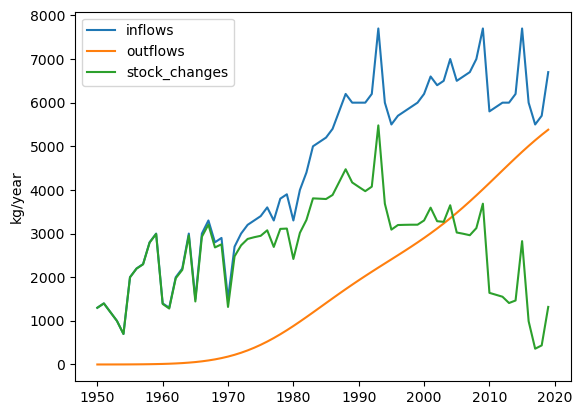

In [8]:
# Visualize the MFA system with the convolution method
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])